In [37]:
import os
import warnings
warnings.filterwarnings("ignore")
from research_analysis.utils.model_loader import ModelLoader
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage, HumanMessage , SystemMessage
from langgraph.checkpoint.memory import MemorySaver


In [38]:
model_loader = ModelLoader()
llm = model_loader.load_llm()

{"timestamp": "2025-12-30T10:57:47.375585Z", "level": "info", "event": "Initializing ApiKeyManager"}
{"timestamp": "2025-12-30T10:57:47.378399Z", "level": "info", "event": "GOOGLE_API_KEY loaded successfully from environment"}
{"timestamp": "2025-12-30T10:57:47.383032Z", "level": "info", "event": "GROQ_API_KEY loaded successfully from environment"}
{"path": "F:\\Agentic AI\\LLMOps\\multi_agent_system\\research_analysis\\config\\config.yaml", "keys": ["astra_db", "embedding_model", "retriever", "llm"], "timestamp": "2025-12-30T10:57:47.414465Z", "level": "info", "event": "Configuration loaded successfully"}
{"config_keys": ["astra_db", "embedding_model", "retriever", "llm"], "timestamp": "2025-12-30T10:57:47.419506Z", "level": "info", "event": "YAML configuration loaded successfully"}
{"provider": "groq", "model": "openai/gpt-oss-120b", "timestamp": "2025-12-30T10:57:47.422490Z", "level": "info", "event": "Loading LLM"}
{"provider": "groq", "model": "openai/gpt-oss-120b", "timestamp": "

In [6]:
llm.invoke("hi")

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hi". We need to respond appropriately. It\'s a simple greeting. We can respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 72, 'total_tokens': 113, 'completion_time': 0.088229154, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.016692114, 'prompt_tokens_details': None, 'queue_time': 0.063360156, 'total_time': 0.104921268}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8a618bed98', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--37fc513c-0aad-4f1e-9d58-8ba18799a7b4-0', usage_metadata={'input_tokens': 72, 'output_tokens': 41, 'total_tokens': 113})

In [39]:
from typing import List 
from typing_extensions import TypedDict
from pydantic import BaseModel , Field

In [40]:
class Analyst(BaseModel):
    name:str = Field(..., description="Name of the analyst")
    role:str = Field(..., description="Role of the analyst in the context of the topic")
    affiliation:str = Field(..., description="Primary affiliation of the analyst")
    description:str = Field(..., description="Brief description of the analyst's expertise and background which focuses, concerns and motives")
    @property
    def profile(self) -> str:
        return f"{self.name}, a {self.role} affiliated with {self.affiliation}. {self.description}" 

In [65]:
class Perspectives(BaseModel):
       analysts: List[Analyst] = Field(description="Comprehensive list of analysts with their roles and affiliations.")

In [54]:
class GenerateAnalystsState(TypedDict):
    topic: str #research topic
    max_analysts: int # number of analyst
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions

In [55]:
analyst = Analyst(name = "Karthik" , role = "GenAI-Analyst", affiliation="OpenAI", description="Expert in analyzing the impact of generative AI on various industries and societal aspects.")
print(analyst.profile)

Karthik, a GenAI-Analyst affiliated with OpenAI. Expert in analyzing the impact of generative AI on various industries and societal aspects.


In [59]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [60]:
print([analyst_instructions.format(
        topic="education",
        max_analysts=4,
        human_analyst_feedback="please exaplain only on AI"
        
        )] + ["Generate the set of analysts."])

['You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:\n\n1. First, review the research topic:\neducation\n\n2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: \n\nplease exaplain only on AI\n\n3. Determine the most interesting themes based upon documents and / or feedback above.\n\n4. Pick the top 4 themes.\n\n5. Assign one analyst to each theme.', 'Generate the set of analysts.']


In [66]:
def create_analyst(state:GenerateAnalystsState):
    """
    it is creating my analyst
    
    """
    topic = state["topic"]
    max_analysts = state["max_analysts"]
    human_analyst_feedback = state.get("human_analyst_feedback","")
    
    structured_llm = llm.with_structured_output(Perspectives)
    
    system_messages = analyst_instructions.format(
        topic=topic,
        max_analysts=max_analysts,
        human_analyst_feedback=human_analyst_feedback
        
        )
    analysts = structured_llm.invoke([SystemMessage(content=system_messages)]+ [HumanMessage(content="Generate the set of analysts.")])
    
    # Write the list of analysis to state
    return {"analysts": analysts.analysts}

In [67]:
create_analyst(
    {'topic': 'health',
    'max_analysts': 2,
    'human_analyst_feedback': 'give the real info'}
    )

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


{'analysts': [Analyst(name='Dr. Maya Patel', role='Public Health Policy Analyst', affiliation='World Health Organization (WHO)', description='Epidemiologist with 15 years experience in global disease surveillance, pandemic preparedness, and health policy formulation. Focuses on translating scientific evidence into actionable policies, addressing vaccine equity, and evaluating the impact of public health interventions.'),
  Analyst(name='Alex Chen, M.D., M.S.', role='Digital Health & Telemedicine Analyst', affiliation='Stanford Center for Digital Health Innovation', description='Physician‑scientist specializing in health informatics, telehealth delivery models, and AI‑driven diagnostics. Leads research on patient outcomes in virtual care, data privacy in digital platforms, and the integration of wearable technology into clinical workflows.')]}

In [68]:
def human_feedback(state):
     """ No-op node that should be interrupted on """
     pass

In [76]:
def should_continue(state):
    """Return the Next Node to execute"""
    feedback = (state.get("human_analyst_feedback") or "").strip().lower()
    if feedback and feedback not in ["", "none", "skip", "done", "continue"]:
        return "create_analyst"
    return END

In [77]:
builder = StateGraph(GenerateAnalystsState)
builder.add_node("create_analyst", create_analyst)
builder.add_node("human_feedback", human_feedback)
builder.add_edge(START , "create_analyst")
builder.add_edge("create_analyst" , "human_feedback")
builder.add_conditional_edges("human_feedback",
                        should_continue,
                        ["create_analyst",
                        END])

In [78]:
memory = MemorySaver()
graph = builder.compile(interrupt_before=["human_feedback"], checkpointer=memory)

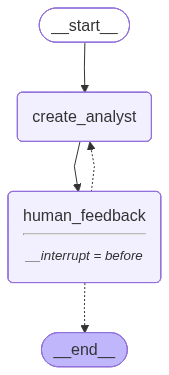

In [52]:
from IPython.display import display , Image
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [79]:

topic = "the benefits of adopting Langgraph as an agent framework"
max_analysts = 4
thread =  {"configurable":{"thread_id":1}}
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Maya Patel
Affiliation: Institute for Scalable AI Systems
Role: Scalability & Performance Analyst
Description: Expert in distributed systems and high-performance computing, focusing on how Langgraph's architecture enables horizontal scaling, low-latency agent orchestration, and efficient resource utilization across cloud and edge environments.
--------------------------------------------------
Name: Liam O'Connor
Affiliation: OpenAI Developer Relations
Role: Developer Productivity Analyst
Description: Full‑stack AI engineer with a background in rapid prototyping and tooling, evaluating Langgraph's declarative graph DSL, debugging utilities, and reusable component library that accelerate agent development cycles and lower the learning curve.
--------------------------------------------------
Name: Prof. Elena García
Affiliation: Center for AI Ethics & Governance
Role: Reliability, Security & Governance Analyst
Description: Researcher specializing in trustworthy AI, assessing L

In [80]:
state = graph.get_state(thread)
state

StateSnapshot(values={'topic': 'the benefits of adopting Langgraph as an agent framework', 'max_analysts': 4, 'analysts': [Analyst(name='Dr. Maya Patel', role='Scalability & Performance Analyst', affiliation='Institute for Scalable AI Systems', description="Expert in distributed systems and high-performance computing, focusing on how Langgraph's architecture enables horizontal scaling, low-latency agent orchestration, and efficient resource utilization across cloud and edge environments."), Analyst(name="Liam O'Connor", role='Developer Productivity Analyst', affiliation='OpenAI Developer Relations', description="Full‑stack AI engineer with a background in rapid prototyping and tooling, evaluating Langgraph's declarative graph DSL, debugging utilities, and reusable component library that accelerate agent development cycles and lower the learning curve."), Analyst(name='Prof. Elena García', role='Reliability, Security & Governance Analyst', affiliation='Center for AI Ethics & Governance'

In [74]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'analysts': [Analyst(name='Dr. Maya Patel', role='Scalability & Performance Analyst', affiliation='Institute for Scalable AI Systems', description="Expert in distributed computing and high-throughput AI pipelines. Focuses on how Langgraph's graph-based execution model enables horizontal scaling, low-latency inference, and efficient resource utilization across clusters."),
  Analyst(name='Prof. Luis Ortega', role='Modularity & Composability Analyst', affiliation='Modular AI Research Lab, University of Barcelona', description="Specializes in software architecture for AI agents. Examines Langgraph's node-based composition, reusable subgraphs, and plug‑in mechanisms that promote clean separation of concerns and rapid prototyping."),
  Analyst(name='Sofia Chen', role='Developer Experience & Debugging Analyst', affiliation='OpenAI Developer Relations', description="Senior engineer and community advocat

In [ ]:
state.next  ##It stops before human feedback

('human_feedback',)

In [81]:
graph.update_state(thread, {"human_analyst_feedback":"along with the genetive ai in future tell me the future of indian team"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0e5708-3cc9-6fd7-8002-02a85f16a0c5'}}

In [82]:

topic = "the benefits of adopting Langgraph as an agent framework"
max_analysts = 4
thread =  {"configurable":{"thread_id":1}}
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Maya Patel
Affiliation: Institute for Scalable AI Systems
Role: Scalability & Performance Analyst
Description: Expert in distributed systems and high-performance computing, focusing on how Langgraph's architecture enables horizontal scaling, low-latency agent orchestration, and efficient resource utilization across cloud and edge environments.
--------------------------------------------------
Name: Liam O'Connor
Affiliation: OpenAI Developer Relations
Role: Developer Productivity Analyst
Description: Full‑stack AI engineer with a background in rapid prototyping and tooling, evaluating Langgraph's declarative graph DSL, debugging utilities, and reusable component library that accelerate agent development cycles and lower the learning curve.
--------------------------------------------------
Name: Prof. Elena García
Affiliation: Center for AI Ethics & Governance
Role: Reliability, Security & Governance Analyst
Description: Researcher specializing in trustworthy AI, assessing L

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Maya Rao
Affiliation: Institute of AI Systems, Bangalore
Role: Technical Architect Analyst
Description: Expert in agent-oriented programming and distributed systems. Focuses on the architectural advantages of Langgraph, such as modular graph composition, fault tolerance, and scalability for large‑scale AI pipelines.
--------------------------------------------------
Name: Prof. Ethan Liu
Affiliation: Center for Generative AI Research, Stanford University
Role: Generative AI Integration Analyst
Description: Specializes in coupling large language models with agent frameworks. Evaluates how Langgraph streamlines prompt chaining, context management, and tool use for generative AI applications.
--------------------------------------------------
Name: Ananya Singh
Affiliation: Tech Innovation Lab, Tata Consultancy Services
Role: Market & Adoption Analyst (India)
Description: Tracks AI adoption trends within Indian enterprises. Analyzes the strategic impact of Langgraph on Indian de

In [83]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'analysts': [Analyst(name='Dr. Maya Patel', role='Scalability & Performance Analyst', affiliation='Institute for Scalable AI Systems', description="Expert in distributed systems and high-performance computing, focusing on how Langgraph's architecture enables horizontal scaling, low-latency agent orchestration, and efficient resource utilization across cloud and edge environments."),
  Analyst(name="Liam O'Connor", role='Developer Productivity Analyst', affiliation='OpenAI Developer Relations', description="Full‑stack AI engineer with a background in rapid prototyping and tooling, evaluating Langgraph's declarative graph DSL, debugging utilities, and reusable component library that accelerate agent development cycles and lower the learning curve."),
  Analyst(name='Prof. Elena García', role='Reliability, Security & Governance Analyst', affiliation='Center for AI Ethics & Governance', description="

In [84]:
state.next

('human_feedback',)

In [85]:
graph.update_state(thread, {"human_analyst_feedback":""}, as_node="human_feedback")
graph.get_state(thread).next

()

In [86]:
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

In [87]:
from IPython.display import Markdown
final_state = graph.get_state(thread)
report = final_state.values.get('final_report')

In [88]:
Markdown(report)

<IPython.core.display.Markdown object>

In [89]:
report